## Importing required libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

# creating dataframe

In [2]:
data = fetch_openml(data_id=41554, as_frame=True)
df = data.frame

In [3]:
df.head()

,Xloc,Yloc,Landuse_1,Landuse_2,Landuse_3,Landuse_4,Rock_1,Rock_2,Rock_3,Rock_4,Rock_5,Cr,Ni,Pb,Zn,Cd,Co,Cu
0,2.386,3.077,0,0,1,0,0,0,1,0,0,38.32,21.32,77.36,92.56,1.740,9.32,25.72
1,2.544,1.972,0,1,0,0,0,1,0,0,0,40.20,29.72,77.88,73.56,1.335,10.00,24.76
2,2.807,3.347,0,1,0,0,0,0,1,0,0,47.00,21.40,30.80,64.80,1.610,10.60,8.88
3,4.308,1.933,0,0,1,0,0,1,0,0,0,43.52,29.72,56.40,90.00,2.150,11.92,22.70
4,4.383,1.081,0,0,1,0,0,0,0,0,1,38.52,26.20,66.40,88.40,1.565,16.32,34.32


## Checking dimensionality

In [4]:
df.shape

(359, 18)

## Checking column names

In [5]:
df.columns

Index(['Xloc', 'Yloc', 'Landuse_1', 'Landuse_2', 'Landuse_3', 'Landuse_4',
       'Rock_1', 'Rock_2', 'Rock_3', 'Rock_4', 'Rock_5', 'Cr', 'Ni', 'Pb',
       'Zn', 'Cd', 'Co', 'Cu'],
      dtype='object')

Cr (Chromium)

Ni (Nickel)

Pb (Lead)

Zn (Zinc)

Co (Cobalt)

Cu (Copper)

target column is Cd (Cadmium)
We predict Cadmium using other metals + location + land type + rock type.

Cadmium (Cd) is predicted using a combination of other metal concentrations (Cr, Ni, Pb, Zn, Co, Cu), geographic location (Xloc, Yloc), land use types, and rock types. These variables influence Cadmium levels because heavy metals often occur together, and environmental factors like land usage and geological composition affect their concentration.

## Getting dataset infomation using info() method

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359 entries, 0 to 358
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Xloc       359 non-null    float64
 1   Yloc       359 non-null    float64
 2   Landuse_1  359 non-null    int64  
 3   Landuse_2  359 non-null    int64  
 4   Landuse_3  359 non-null    int64  
 5   Landuse_4  359 non-null    int64  
 6   Rock_1     359 non-null    int64  
 7   Rock_2     359 non-null    int64  
 8   Rock_3     359 non-null    int64  
 9   Rock_4     359 non-null    int64  
 10  Rock_5     359 non-null    int64  
 11  Cr         359 non-null    float64
 12  Ni         359 non-null    float64
 13  Pb         359 non-null    float64
 14  Zn         359 non-null    float64
 15  Cd         359 non-null    float64
 16  Co         359 non-null    float64
 17  Cu         359 non-null    float64
dtypes: float64(9), int64(9)
memory usage: 50.6 KB


## Statistical information about numerical column

In [7]:
df.describe()

,Xloc,Yloc,Landuse_1,Landuse_2,Landuse_3,Landuse_4,Rock_1,Rock_2,Rock_3,Rock_4,Rock_5,Cr,Ni,Pb,Zn,Cd,Co,Cu
count,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000
mean,2.963384,2.631769,0.142061,0.228412,0.607242,0.022284,0.211699,0.345404,0.247911,0.016713,0.178273,35.017827,20.018217,54.630975,75.881894,1.288237,9.439086,23.585471
std,0.980822,1.269089,0.349600,0.420396,0.489045,0.147812,0.409083,0.476163,0.432402,0.128373,0.383277,10.662561,8.094140,33.097935,30.818669,0.859098,3.568250,22.267948
min,0.491000,0.524000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.320000,1.980000,18.680000,25.000000,0.135000,1.552000,3.552000
25%,2.260500,1.510500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,27.640000,14.600000,36.320000,54.600000,0.652500,6.660000,10.470000
50%,3.040000,2.489000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,34.800000,20.680000,46.800000,73.560000,1.100000,9.840000,17.200000
75%,3.674000,3.652000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,41.460000,25.380000,60.200000,90.000000,1.680000,12.100000,26.920000
max,4.920000,5.690000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,70.000000,53.200000,300.000000,259.840000,5.129000,20.600000,166.400000


## lets check relationship between column using heatmap

In [8]:
df.corr()

,Xloc,Yloc,Landuse_1,Landuse_2,Landuse_3,Landuse_4,Rock_1,Rock_2,Rock_3,Rock_4,Rock_5,Cr,Ni,Pb,Zn,Cd,Co,Cu
Xloc,1.000000,0.207501,0.120021,-0.047390,-0.033332,-0.038805,-0.240403,0.320175,-0.293959,0.141664,0.143009,-0.073421,0.204230,-0.108522,0.060593,0.106245,0.246165,-0.031474
Yloc,0.207501,1.000000,0.061257,0.065644,-0.075816,-0.080740,0.119937,-0.134070,-0.087004,-0.019042,0.143083,0.003401,-0.106640,-0.232854,-0.098785,0.074458,-0.169318,-0.133311
Landuse_1,0.120021,0.061257,1.000000,-0.221400,-0.505974,-0.061433,0.003972,0.241369,-0.141236,0.133669,-0.189535,-0.198269,-0.090568,-0.059129,-0.240865,0.042614,-0.190773,-0.267392
Landuse_2,-0.047390,0.065644,-0.221400,1.000000,-0.676528,-0.082141,-0.119532,0.051308,0.163979,-0.019175,-0.114736,0.414111,0.224980,0.054849,0.201611,0.289550,0.142181,0.011907
Landuse_3,-0.033332,-0.075816,-0.505974,-0.676528,1.000000,-0.187720,0.095636,-0.219491,-0.040217,-0.073123,0.240472,-0.199041,-0.119830,-0.015813,-0.001255,-0.269063,0.011549,0.161108
Landuse_4,-0.038805,-0.080740,-0.061433,-0.082141,-0.187720,1.000000,0.014154,0.009397,0.000730,-0.019682,-0.021013,-0.050303,-0.029198,0.036172,0.000432,-0.034093,0.008618,0.065529
Rock_1,-0.240403,0.119937,0.003972,-0.119532,0.095636,0.014154,1.000000,-0.376435,-0.297527,-0.067562,-0.241375,-0.294806,-0.496224,-0.168977,-0.230738,-0.124872,-0.540175,-0.135566
Rock_2,0.320175,-0.134070,0.241369,0.051308,-0.219491,0.009397,-0.376435,1.000000,-0.417052,-0.094703,-0.338342,0.048960,0.444101,0.025253,0.040385,0.038571,0.311911,-0.092767
Rock_3,-0.293959,-0.087004,-0.141236,0.163979,-0.040217,0.000730,-0.297527,-0.417052,1.000000,-0.074852,-0.267419,0.240386,0.028459,0.153815,0.154884,0.114009,0.135492,0.132771
Rock_4,0.141664,-0.019042,0.133669,-0.019175,-0.073123,-0.019682,-0.067562,-0.094703,-0.074852,1.000000,-0.060725,0.004924,0.046267,0.006031,-0.013762,0.036614,-0.037286,0.010756


## lets visualize using seaborn

<Axes: >

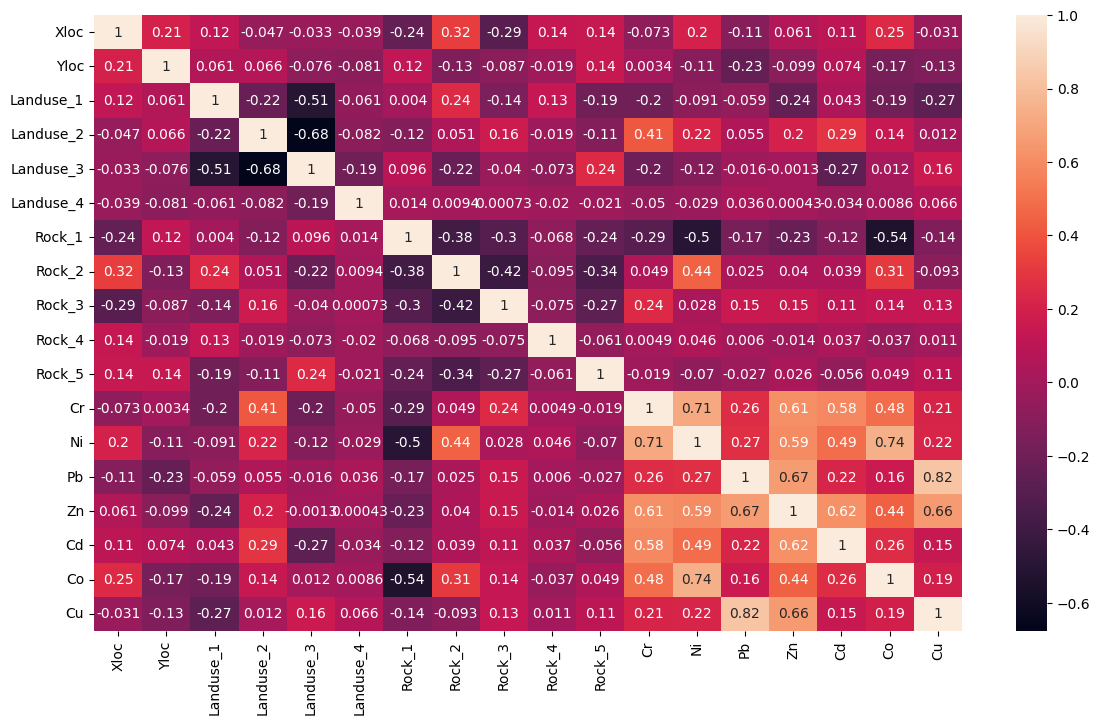

In [9]:
plt.figure(figsize=(14,8))
sns.heatmap(df.corr(),annot=True)

#### by seeing heatmap we can say Cr,Ni and Zn have slightly positive strong relation with Cd

## lets use scatter plot see relation b/w them

### 1. for cu and cd

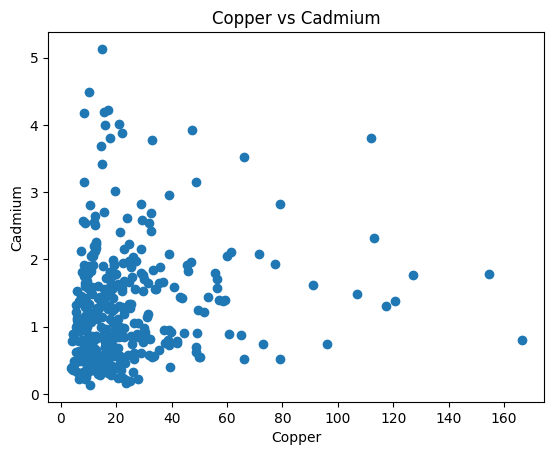

In [10]:
plt.scatter(df['Cu'], df['Cd'])
plt.xlabel("Copper")
plt.ylabel("Cadmium")
plt.title("Copper vs Cadmium")
plt.show()

### 2. for cd and zn

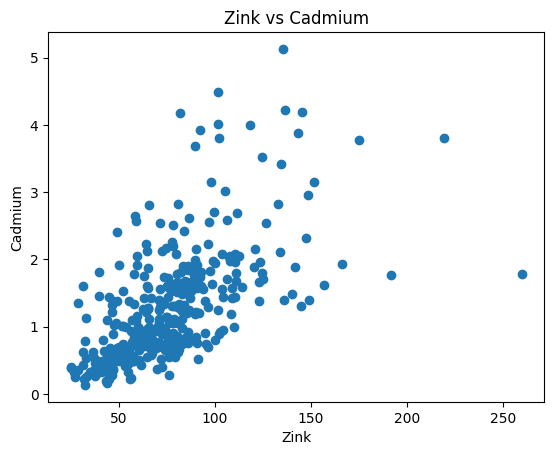

In [11]:
plt.scatter(df['Zn'], df['Cd'])
plt.xlabel("Zink")
plt.ylabel("Cadmium")
plt.title("Zink vs Cadmium")
plt.show()

### for Ni and Cd

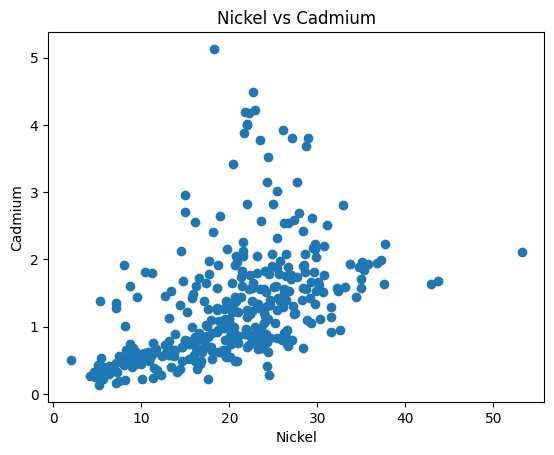

In [12]:
plt.scatter(df['Ni'], df['Cd'])
plt.xlabel("Nickel")
plt.ylabel("Cadmium")
plt.title("Nickel vs Cadmium")
plt.show()

cu and pb are highly correlated

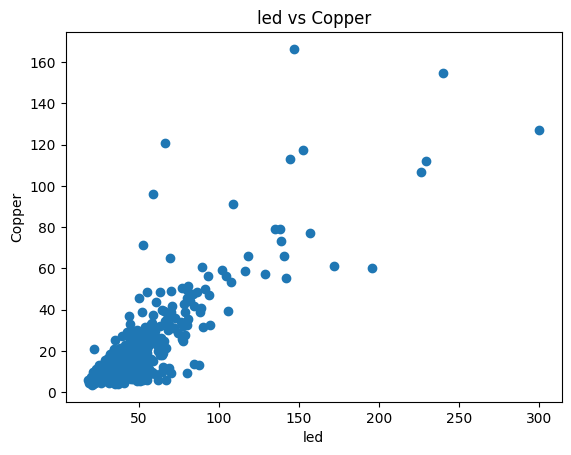

In [13]:
plt.scatter(df['Pb'], df['Cu'])
plt.xlabel("led")
plt.ylabel("Copper")
plt.title("led vs Copper")
plt.show()

## lets use pair plot to check multi-colinearity

<Figure size 1400x800 with 0 Axes>

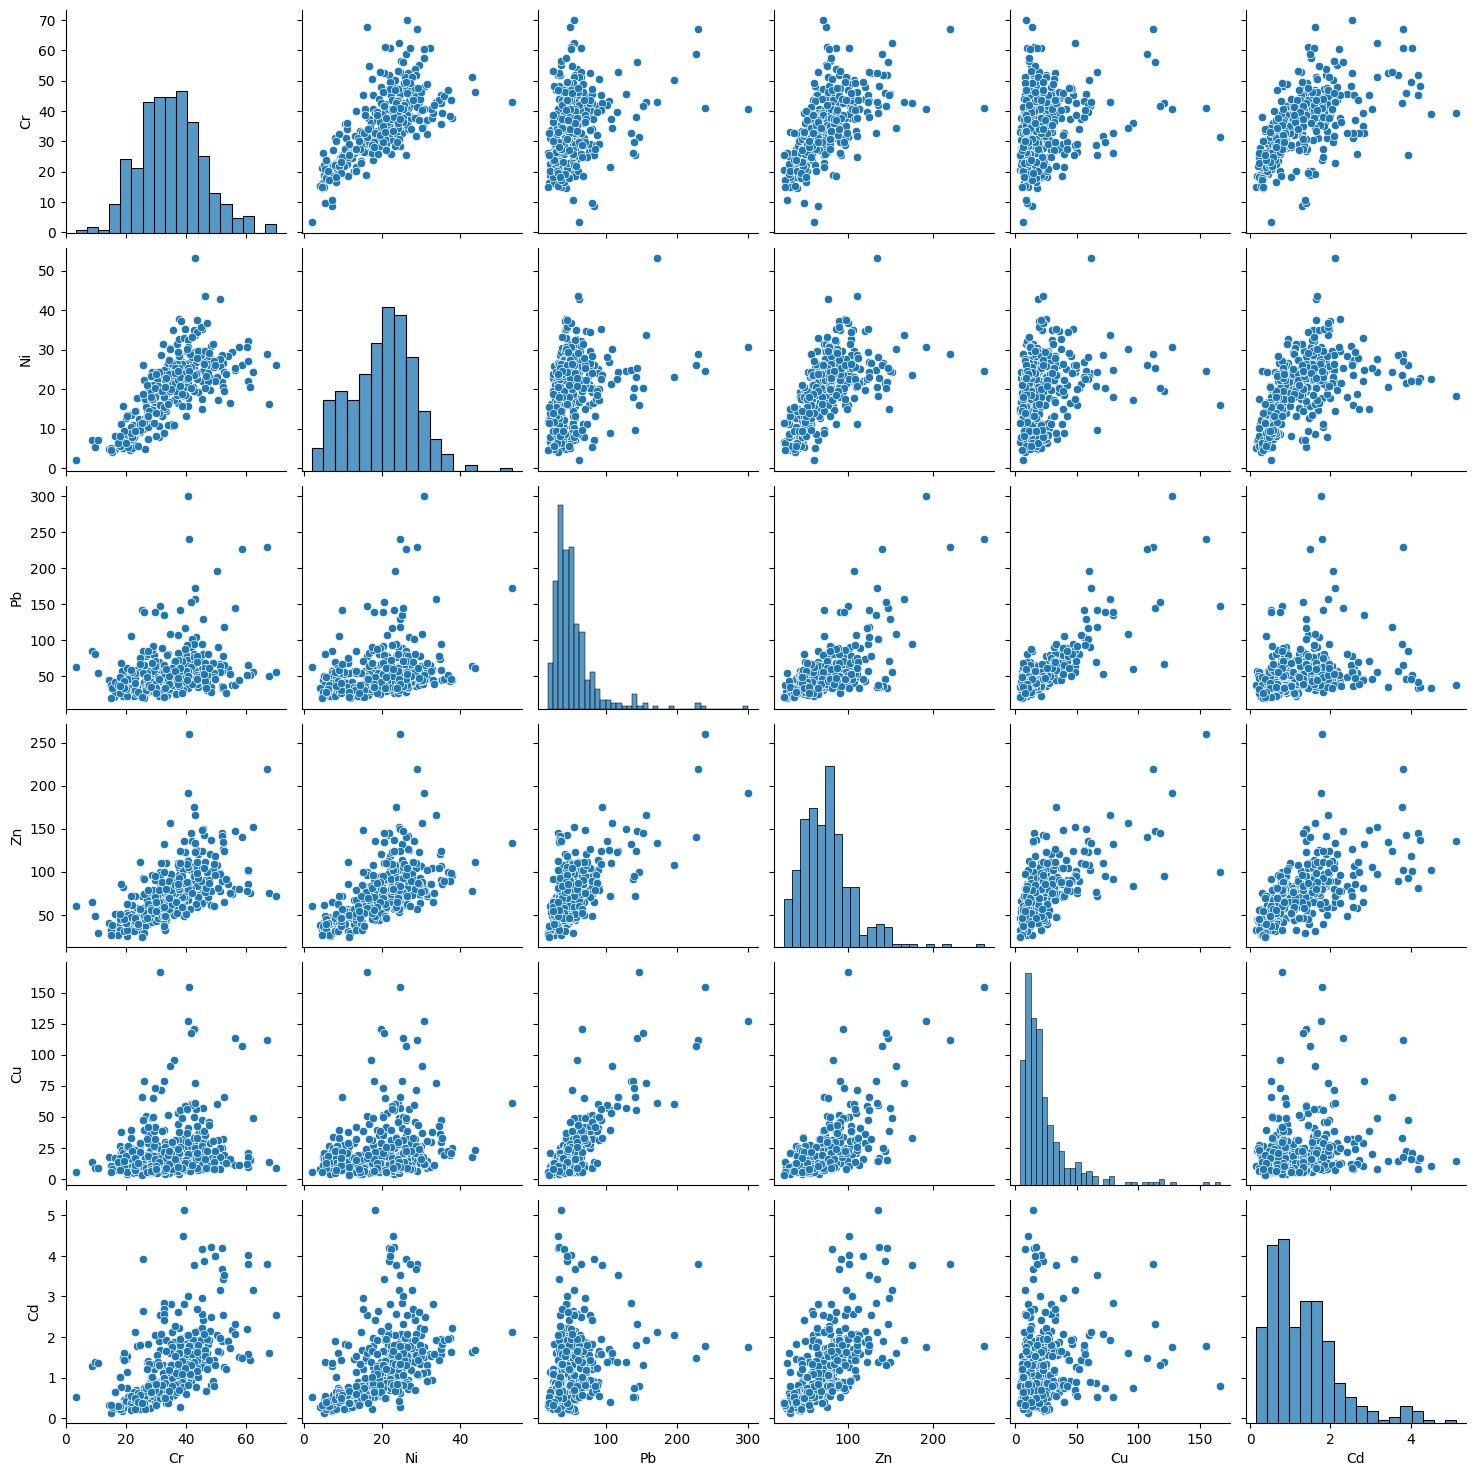

In [14]:
plt.figure(figsize=(14,8))
sns.pairplot(df[['Cr','Ni','Pb','Zn','Cu','Cd']])
plt.show()

#### by observing pair plot we can say,it indicating linear correlation, but variance and spread suggest non-linearity, which justifies using polynomial features

#### Polynomial features are introduced to capture non-linear relationships between variables. In real-world datasets like metal concentrations, the relationship between features and the target variable is not always linear. Polynomial features allow the model to learn complex patterns and interactions between variables.

##  data preperation

In [15]:
x = df.drop(columns=['Cd'])
y= df['Cd']

## Polynomial features

## to scale the data using Standard scaler

In [16]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

## splitting data into training and tesing part

In [17]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## training Models

### 1. using LinearRegression

In [18]:
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

#### coefficient and intercept lr model

In [19]:
lr.coef_

array([ 0.0645583 ,  0.0096397 ,  0.32739966,  0.0352258 , -0.26357243,
       -0.09905302,  0.10864963, -0.16802899,  0.06504222, -0.03243673,
        0.02677388,  0.01531263,  0.01342869, -0.00489829,  0.02274537,
       -0.03079161, -0.00836067])

In [20]:
lr.intercept_

np.float64(-0.5586160004757099)

#### lr model prediction

In [21]:
y_pred_lr = lr.predict(x_test)
y_pred_lr

array([1.37046598, 1.88252024, 0.94895426, 0.2495999 , 1.08985981,
       1.8338885 , 0.6372778 , 1.50980033, 2.82317299, 2.11787942,
       1.02679541, 1.04766064, 1.25687235, 1.15848279, 1.30930114,
       1.79936219, 1.73827621, 1.75535452, 0.64649864, 1.15882511,
       0.2064931 , 0.28164311, 1.19122377, 3.13880571, 0.2992564 ,
       0.46447567, 0.2187064 , 1.61276008, 1.22309444, 1.08373899,
       1.79054518, 1.09514959, 1.1334262 , 1.45870212, 0.66721228,
       3.80270429, 1.57132693, 0.61206911, 1.13795463, 0.69034359,
       1.68917851, 3.5346813 , 0.77265782, 0.86201648, 0.57073342,
       0.82105438, 0.34269507, 1.35844967, 0.95636501, 1.82638665,
       2.46227243, 1.26534149, 0.47535432, 0.75543093, 1.322492  ,
       1.08704515, 1.58603596, 0.69569458, 2.12273072, 0.99545252,
       2.83926515, 2.73484632, 1.15191197, 1.29841208, 3.41422924,
       0.67579703, 1.80974928, 1.95252425, 1.94746385, 0.49626187,
       0.24305736, 1.77687285])

### 2. using Ridge

In [22]:
ridge = Ridge(alpha=1.0)
ridge.fit(x_train, y_train)

Ridge()

### coefficient and intercept of lr model

In [23]:
ridge.coef_

array([ 0.06368478,  0.01060422,  0.31424265,  0.0326649 , -0.26251354,
       -0.08439401,  0.10205193, -0.16373582,  0.06161997, -0.02298946,
        0.02305338,  0.01538887,  0.0131295 , -0.00484169,  0.02275436,
       -0.03104242, -0.00846597])

In [24]:
ridge.intercept_

np.float64(-0.551317307538745)

#### ridge model prediction

In [25]:
y_pred_ridge = ridge.predict(x_test)
y_pred_ridge


array([1.36452352, 1.8840735 , 0.94464371, 0.24912778, 1.09612753,
       1.81748132, 0.63962692, 1.50341464, 2.81096594, 2.11519691,
       1.0233383 , 1.05159442, 1.26087512, 1.15587501, 1.30743797,
       1.80129619, 1.73702442, 1.75501759, 0.66554121, 1.15251911,
       0.21201326, 0.28764604, 1.19936932, 3.1385245 , 0.30085146,
       0.46833202, 0.22410854, 1.6140441 , 1.2198332 , 1.08252788,
       1.79674254, 1.09589319, 1.1403758 , 1.46114149, 0.66762898,
       3.79971769, 1.57361453, 0.60979087, 1.1330827 , 0.70927999,
       1.68299573, 3.53178167, 0.77634208, 0.86434107, 0.57038395,
       0.81879604, 0.34312325, 1.36169828, 0.95928885, 1.83102574,
       2.45695645, 1.26022657, 0.47693661, 0.75967   , 1.31596   ,
       1.08711661, 1.58983583, 0.69352911, 2.11894577, 0.99618523,
       2.83826301, 2.73068789, 1.15611753, 1.30605544, 3.41007198,
       0.67849647, 1.81277078, 1.94664363, 1.94814972, 0.49836706,
       0.24414057, 1.78395526])

### 3. using Lasso

In [26]:
lasso = Lasso(alpha=1.0)
lasso.fit(x_train, y_train)

Lasso()

### coefficient and intercept of lasso model

In [27]:
lasso.coef_

array([ 0.        ,  0.        ,  0.        ,  0.        , -0.        ,
       -0.        ,  0.        , -0.        ,  0.        ,  0.        ,
       -0.        ,  0.00865479,  0.        , -0.0015212 ,  0.02059651,
       -0.        , -0.01053551])

In [28]:
lasso.intercept_

np.float64(-0.22142171049590553)

#### lasso model prediction

In [29]:
y_pred_lasso = lasso.predict(x_test)
y_pred_lasso

array([1.52571458, 1.73829052, 1.06489609, 0.5026633 , 1.40354296,
       1.15449339, 0.75178496, 1.6139334 , 2.06816088, 2.16344934,
       0.88778124, 1.22918193, 1.40234321, 1.31898729, 1.46444238,
       1.93443968, 1.53069643, 1.86821641, 0.95954262, 1.03802403,
       0.49799905, 0.60309376, 1.40159573, 2.8245998 , 0.61136907,
       0.60741959, 0.50321041, 1.5200196 , 1.31517516, 1.25771181,
       1.89604247, 1.36354479, 1.4575443 , 1.50952434, 0.65648237,
       3.34641503, 1.65592674, 0.44481112, 0.84478093, 0.73605079,
       1.47333032, 2.84235541, 0.98533906, 1.1927031 , 0.77069049,
       0.99448483, 0.57726708, 1.23740305, 1.06634232, 1.72259284,
       2.22342407, 1.04009993, 0.73234776, 1.04468194, 1.24256294,
       0.89464232, 1.68396816, 0.92937694, 1.59947895, 0.95188172,
       2.31185002, 2.44706464, 1.20152918, 1.60891648, 2.78453797,
       0.71391095, 1.67040262, 1.58494173, 2.02186765, 0.77022699,
       0.55571466, 1.95059133])

## RMSE & R2 Score

In [30]:
def evaluate(y_test, y_pred):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    return rmse, r2

print("Linear model:", evaluate(y_test, y_pred_lr))
print("Ridge model:", evaluate(y_test, y_pred_ridge))
print("Lasso model:", evaluate(y_test, y_pred_lasso))

Linear model: (np.float64(0.49064557787713015), 0.6290008116517805)
Ridge model: (np.float64(0.4898536198124724), 0.6301975152858628)
Lasso model: (np.float64(0.5055601912966892), 0.60610277558193)


### Identify which features Lasso reduced to exactly zero (feature selection).

In [31]:
zero_features = np.sum(lasso.coef_ == 0)
print("Number of features reduced to zero:", zero_features)

Number of features reduced to zero: 13


Ridge Regression performed the best with the lowest RMSE (0.4898) and highest R² (0.6301), although the improvement over Linear Regression was minimal. This indicates that the dataset has a mostly linear relationship. Regularization was still necessary to handle multicollinearity among metal features. Lasso Regression removed 13 features, which slightly reduced performance due to loss of useful information.